In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

In [3]:
ROOT = '/kaggle/input/datasets/awsaf49/artifact-dataset'

CLASS_MAP = {
    # 8 real sources
    'afhq': 'real', 'celebahq': 'real', 'coco': 'real', 'ffhq': 'real',
    'imagenet': 'real', 'landscape': 'real', 'lsun': 'real', 'metfaces': 'real',

    # 13 GANs
    'big_gan': 'gan', 'cips': 'gan', 'cycle_gan': 'gan', 'gansformer': 'gan',
    'gau_gan': 'gan', 'pro_gan': 'gan', 'projected_gan': 'gan', 'star_gan': 'gan',
    'stylegan1': 'gan', 'stylegan2': 'gan', 'stylegan3': 'gan',
    'denoising_diffusion_gan': 'gan', 'diffusion_gan': 'gan',

    # 7 diffusion
    'ddpm': 'diffusion', 'glide': 'diffusion', 'latent_diffusion': 'diffusion',
    'palette': 'diffusion', 'stable_diffusion': 'diffusion',
    'vq_diffusion': 'diffusion', 'sfhq': 'diffusion',

    # 5 misc (not used)
    'face_synthetics': 'other', 'generative_inpainting': 'other',
    'lama': 'other', 'mat': 'other', 'taming_transformer': 'other',
}

# ---------- load every metadata.csv ----------
frames = []
for folder, cls in CLASS_MAP.items():
    csv_path = os.path.join(ROOT, folder, 'metadata.csv')
    if not os.path.exists(csv_path):
        print(f"  !! no metadata.csv in {folder}")
        continue
    d = pd.read_csv(csv_path)
    d['source'] = folder
    d['class'] = cls
    d['full_path'] = ROOT + '/' + folder + '/' + d['image_path']
    frames.append(d[['full_path', 'source', 'class']])

master = pd.concat(frames, ignore_index=True)
print(f"Total indexed: {len(master):,}\n")
print(master.groupby('class').size(), "\n")
print(master.groupby(['class', 'source']).size().to_string())

Total indexed: 2,496,738

class
diffusion      89243
gan          1248406
other         221705
real          937384
dtype: int64 

class      source                 
diffusion  ddpm                           896
           glide                        20903
           latent_diffusion             20000
           palette                       6000
           sfhq                         10000
           stable_diffusion             21444
           vq_diffusion                 10000
gan        big_gan                      10000
           cips                         11200
           cycle_gan                    15210
           denoising_diffusion_gan      10000
           diffusion_gan                15507
           gansformer                   10000
           gau_gan                       7000
           pro_gan                      40000
           projected_gan                12000
           star_gan                      9995
           stylegan1                    10000
      

In [4]:
SEED = 42
rng = np.random.RandomState(SEED)
TARGETS = {'real': 60000, 'gan': 30000, 'diffusion': 30000}

def sample_class(df, cls, total, rng):
    pool = df[df['class'] == cls]
    sources = sorted(pool['source'].unique())
    avail = {s: len(pool[pool['source'] == s]) for s in sources}

    quota = {s: 0 for s in sources}
    remaining = total
    active = set(sources)

    # Give everyone an equal share; anyone who can't fill it gets capped,
    # and their leftover is redistributed to the rest. Repeat until settled.
    while remaining > 0 and active:
        share = max(1, remaining // len(active))
        progressed = False
        for s in sorted(active):
            if remaining <= 0:
                break
            take = min(share, avail[s] - quota[s], remaining)
            if take > 0:
                quota[s] += take
                remaining -= take
                progressed = True
            if quota[s] >= avail[s]:
                active.discard(s)
        if not progressed:
            break

    picked = []
    for s, n in quota.items():
        if n == 0:
            continue
        sub = pool[pool['source'] == s]
        picked.append(sub.sample(n=n, random_state=rng))
    return pd.concat(picked, ignore_index=True)

parts = [sample_class(master, c, n, rng) for c, n in TARGETS.items()]
sampled = pd.concat(parts, ignore_index=True)

sampled['label'] = (sampled['class'] != 'real').astype(int)
sampled = sampled.sample(frac=1, random_state=SEED).reset_index(drop=True)

# 80/10/10, stratified by source so every architecture appears in every split
def add_split(df, rng):
    df = df.copy()
    df['split'] = 'train'
    for s in df['source'].unique():
        idx = df.index[df['source'] == s].to_numpy()
        rng.shuffle(idx)
        n = len(idx)
        n_tr, n_va = int(0.8 * n), int(0.1 * n)
        df.loc[idx[n_tr:n_tr + n_va], 'split'] = 'val'
        df.loc[idx[n_tr + n_va:], 'split'] = 'test'
    return df

sampled = add_split(sampled, np.random.RandomState(SEED))
sampled.to_csv('/kaggle/working/sampled_40k.csv', index=False)

print(f"Total: {len(sampled):,}\n")
print(sampled.groupby('class').size(), "\n")
print(sampled.groupby(['class', 'source']).size().to_string(), "\n")
print(sampled.groupby(['split', 'label']).size(), "\n")
print(sampled[['full_path', 'source', 'class', 'label', 'split']].head())

Total: 120,000

class
diffusion    30000
gan          30000
real         60000
dtype: int64 

class      source                 
diffusion  ddpm                        896
           glide                      4851
           latent_diffusion           4851
           palette                    4851
           sfhq                       4851
           stable_diffusion           4850
           vq_diffusion               4850
gan        big_gan                    2308
           cips                       2308
           cycle_gan                  2308
           denoising_diffusion_gan    2308
           diffusion_gan              2308
           gansformer                 2308
           gau_gan                    2308
           pro_gan                    2308
           projected_gan              2308
           star_gan                   2307
           stylegan1                  2307
           stylegan2                  2307
           stylegan3                  2307
real       

In [5]:
# =====================================================================
# CELL 1 — imports, raw transforms (NO Normalize: utils expects [0,1])
# =====================================================================
import os, time, joblib
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

SIZE = 224
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Same augmentation as the CNN saw, but WITHOUT Normalize.
# The gradient/FFT functions need pixel values in [0,1].
raw_train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.OneOf([
        A.ImageCompression(quality_range=(30, 95), p=1.0),
        A.GaussianBlur(blur_limit=(3, 7), sigma_limit=(0.3, 2.2), p=1.0),
        A.Downscale(scale_range=(0.25, 0.75),
                    interpolation_pair={'downscale': 0, 'upscale': 1}, p=1.0),
    ], p=0.7),
    A.OneOf([
        A.GaussNoise(std_range=(0.01, 0.12), p=1.0),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=1.0),
    ], p=0.5),
    A.RandomResizedCrop(size=(SIZE, SIZE), scale=(0.7, 1.0), p=1.0),
    ToTensorV2(),
])

raw_eval_tf = A.Compose([
    A.Resize(SIZE, SIZE),
    ToTensorV2(),
])

In [6]:
# =====================================================================
# CELL 2 — feature extractors (GPU, batched)
# =====================================================================

GRAD_COLS = ['mean_mag', 'cov_xx', 'cov_yy', 'cov_xy', 'trace', 'det'] + \
            [f'mag_hist_{i}' for i in range(8)]
FFT_COLS  = [f'radial_{i}' for i in range(8)] + ['hf_ratio']
ALL_COLS  = GRAD_COLS + FFT_COLS


def _luma(images):
    """RGB -> grayscale luminance. images: (B,3,H,W) in [0,1]."""
    return (0.2126 * images[:, 0:1] +
            0.7152 * images[:, 1:2] +
            0.0722 * images[:, 2:3])


def extract_gradient_features(images):
    """(B,3,H,W) in [0,1] -> (B,14) tensor."""
    B = images.shape[0]
    luma = _luma(images)

    sx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]],
                      dtype=torch.float32, device=images.device).view(1,1,3,3) / 8.0
    sy = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]],
                      dtype=torch.float32, device=images.device).view(1,1,3,3) / 8.0

    gx = F.conv2d(luma, sx, padding=1)
    gy = F.conv2d(luma, sy, padding=1)

    mag = torch.sqrt(gx**2 + gy**2)
    mean_mag = mag.mean(dim=(1,2,3))

    gxf, gyf = gx.view(B,-1), gy.view(B,-1)
    gxc = gxf - gxf.mean(dim=1, keepdim=True)
    gyc = gyf - gyf.mean(dim=1, keepdim=True)

    cov_xx = (gxc*gxc).mean(dim=1)
    cov_yy = (gyc*gyc).mean(dim=1)
    cov_xy = (gxc*gyc).mean(dim=1)
    trace  = cov_xx + cov_yy
    det    = torch.clamp(cov_xx*cov_yy - cov_xy**2, min=0.0)

    hist = torch.stack([torch.histc(mag[i], bins=8, min=0, max=1) for i in range(B)])

    return torch.cat([
        mean_mag[:,None], cov_xx[:,None], cov_yy[:,None], cov_xy[:,None],
        trace[:,None], det[:,None], hist
    ], dim=1)


# Radial masks depend only on H,W. Build once, reuse for every batch.
_MASK_CACHE = {}

def _radial_masks(H, W, device, n_bins=8):
    key = (H, W, str(device), n_bins)
    if key in _MASK_CACHE:
        return _MASK_CACHE[key]
    cy, cx = H//2, W//2
    yy = torch.arange(H, device=device, dtype=torch.float32).view(-1,1)
    xx = torch.arange(W, device=device, dtype=torch.float32).view(1,-1)
    radius = torch.sqrt((xx-cx)**2 + (yy-cy)**2)
    max_r = min(H, W) / 2.0
    rings = [((radius >= (i/n_bins)*max_r) & (radius < ((i+1)/n_bins)*max_r))
             for i in range(n_bins)]
    hf = radius > max_r*0.7
    lf = radius < max_r*0.3
    _MASK_CACHE[key] = (rings, hf, lf)
    return rings, hf, lf


def extract_fft_features(images):
    """(B,3,H,W) in [0,1] -> (B,9) tensor."""
    gray = _luma(images)[:, 0]                       # (B,H,W)
    H, W = gray.shape[-2:]
    rings, hf, lf = _radial_masks(H, W, images.device)

    spec = torch.fft.fftshift(torch.fft.fft2(gray), dim=(-2,-1)).abs()

    radial = torch.stack([spec[:, m].mean(dim=1) for m in rings], dim=1)  # (B,8)
    hf_e = spec[:, hf].mean(dim=1)
    lf_e = spec[:, lf].mean(dim=1)
    ratio = (hf_e / (lf_e + 1e-10))[:, None]

    return torch.cat([radial, ratio], dim=1)

In [7]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class ArtiFactDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.array(Image.open(row['full_path']).convert("RGB"))
        if self.transform:
            img = self.transform(image=img)['image']
        label = torch.tensor(row['label'], dtype=torch.float32)
        return img, label

In [8]:
# =====================================================================
# CELL 3 — run extraction over a split
# =====================================================================

def build_features(df, transform, tag, batch_size=128, workers=4):
    """Returns (X, y) as numpy arrays. X is (N,23)."""
    ds = ArtiFactDataset(df, transform=transform)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False,
                    num_workers=workers, pin_memory=True)

    feats, labels = [], []
    t0 = time.time()
    with torch.no_grad():
        for i, (x, y) in enumerate(dl):
            x = x.to(device, non_blocking=True).float()
            # ToTensorV2 keeps uint8 scale, so divide if needed
            if x.max() > 1.5:
                x = x / 255.0
            g = extract_gradient_features(x)
            f = extract_fft_features(x)
            feats.append(torch.cat([g, f], dim=1).cpu().numpy())
            labels.append(y.numpy())
            if i % 100 == 0:
                print(f"  {tag}: batch {i}/{len(dl)}  {time.time()-t0:.0f}s", flush=True)

    X = np.concatenate(feats).astype(np.float32)
    y = np.concatenate(labels).astype(int)
    print(f"{tag}: {X.shape} in {time.time()-t0:.0f}s")
    return X, y


train_df = sampled[sampled['split'] == 'train']
val_df   = sampled[sampled['split'] == 'val']
test_df  = sampled[sampled['split'] == 'test']

# 30k is plenty for a 23-feature tree model. Full set adds nothing.
feat_train_df = train_df.sample(n=min(30000, len(train_df)), random_state=42)

X_tr, y_tr = build_features(feat_train_df, raw_train_tf, 'train')
X_va, y_va = build_features(val_df,        raw_eval_tf,  'val')
X_te, y_te = build_features(test_df,       raw_eval_tf,  'test')

np.savez('/kaggle/working/classical_features.npz',
         X_tr=X_tr, y_tr=y_tr, X_va=X_va, y_va=y_va, X_te=X_te, y_te=y_te)
print("features cached")

  train: batch 0/235  4s
  train: batch 100/235  38s
  train: batch 200/235  73s
train: (30000, 23) in 85s
  val: batch 0/94  1s
val: (11983, 23) in 33s
  test: batch 0/94  2s
test: (12031, 23) in 33s
features cached


In [9]:
# =====================================================================
# CELL 4 — train 3 random forests, evaluate, save
# =====================================================================

GRAD_IDX = list(range(0, 14))
FFT_IDX  = list(range(14, 23))
ALL_IDX  = list(range(0, 23))

BRANCHES = {
    'gradient': GRAD_IDX,
    'fft':      FFT_IDX,
    'combined': ALL_IDX,
}

models, results = {}, []

for name, idx in BRANCHES.items():
    rf = RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=4,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced',
    )
    rf.fit(X_tr[:, idx], y_tr)

    p_va = rf.predict_proba(X_va[:, idx])[:, 1]
    p_te = rf.predict_proba(X_te[:, idx])[:, 1]

    results.append(dict(
        branch=name,
        n_features=len(idx),
        val_acc=accuracy_score(y_va, p_va > 0.5),
        val_auc=roc_auc_score(y_va, p_va),
        test_acc=accuracy_score(y_te, p_te > 0.5),
        test_auc=roc_auc_score(y_te, p_te),
    ))
    models[name] = rf
    joblib.dump(rf, f'/kaggle/working/rf_{name}.joblib')

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

# which features actually mattered
imp = pd.Series(models['combined'].feature_importances_, index=ALL_COLS)
print("\ntop 10 features:")
print(imp.sort_values(ascending=False).head(10).to_string())

joblib.dump({'grad_cols': GRAD_COLS, 'fft_cols': FFT_COLS,
             'all_cols': ALL_COLS, 'branches': BRANCHES},
            '/kaggle/working/rf_meta.joblib')

  branch  n_features  val_acc  val_auc  test_acc  test_auc
gradient          14 0.572394 0.600765  0.566536  0.595834
     fft           9 0.653092 0.728490  0.649904  0.726426
combined          23 0.668364 0.748970  0.659463  0.747407

top 10 features:
hf_ratio    0.061789
radial_4    0.060008
radial_3    0.058526
radial_2    0.055776
mean_mag    0.055040
radial_6    0.054852
radial_5    0.054714
radial_7    0.054372
radial_0    0.053080
cov_xx      0.052949


['/kaggle/working/rf_meta.joblib']

In [10]:
# ============================================================
# CELL A — load all four models
# ============================================================
import os, time, joblib
import numpy as np, pandas as pd, torch
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score

MODEL_DIR = '/kaggle/input/datasets/part44/modelrfcnn'
print(os.listdir(MODEL_DIR))          # confirm the filenames

SIZE = 224
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---- CNN ----
model = timm.create_model('convnext_tiny', pretrained=False, num_classes=1)
state = torch.load(f'{MODEL_DIR}/best_model.pth', map_location=device)
if isinstance(state, dict) and 'model_state_dict' in state:
    state = state['model_state_dict']
model.load_state_dict(state)
model = model.to(device).eval()

# ---- Random forests ----
rf_models = {n: joblib.load(f'{MODEL_DIR}/rf_{n}.joblib')
             for n in ['gradient', 'fft', 'combined']}

FEAT_IDX = {'gradient': list(range(0, 14)),
            'fft':      list(range(14, 23)),
            'combined': list(range(0, 23))}

print("device:", device, "| loaded:", list(rf_models))

['rf_combined.joblib', 'rf_fft.joblib', 'best_model.pth', 'rf_gradient.joblib']
device: cuda | loaded: ['gradient', 'fft', 'combined']


In [11]:
def build_eval_tf(*steps):
    """
    build_eval_tf()                             -> clean
    build_eval_tf(('jpeg', 30))                 -> single
    build_eval_tf(('rescale', 0.5), ('jpeg', 50))  -> chained, in order
    """
    ops = []
    for name, param in steps:
        if name not in DEGRADATIONS:
            raise ValueError(f"unknown '{name}'. options: {list(DEGRADATIONS)}")
        ops.append(DEGRADATIONS[name](param))
    return A.Compose(ops + [
        A.Resize(SIZE, SIZE),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])

MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

DEGRADATIONS = {
    'jpeg':    lambda q: A.ImageCompression(quality_range=(q, q), p=1.0),
    'blur':    lambda s: A.GaussianBlur(blur_limit=(0, 0), sigma_limit=(s, s), p=1.0),
    'noise':   lambda s: A.GaussNoise(std_range=(s, s), mean_range=(0, 0), p=1.0),
    'jitter':  lambda a: A.ColorJitter(brightness=a, contrast=a,
                                       saturation=a, hue=0.0, p=1.0),
    'crop':    lambda f: A.CenterCrop(int(200*f), int(200*f), p=1.0),
    'rescale': lambda s: A.Downscale(scale_range=(s, s),
                                     interpolation_pair={'downscale': 0, 'upscale': 1},
                                     p=1.0),
}
# ============================================================
# CELL B — robustness table
# ============================================================
THRESH, RF_W = 0.35, 0.2

SUITE = {
    'clean':        (),
    'jpeg_90':      (('jpeg', 90),),
    'jpeg_50':      (('jpeg', 50),),
    'jpeg_30':      (('jpeg', 30),),
    'blur_0.5':     (('blur', 0.5),),
    'blur_2.0':     (('blur', 2.0),),
    'noise_0.05':   (('noise', 0.05),),
    'jitter_20':    (('jitter', 0.2),),
    'crop_80':      (('crop', 0.8),),
    'rescale_0.5':  (('rescale', 0.5),),
    'rescale_0.25': (('rescale', 0.25),),
    'social_media': (('rescale', 0.5), ('jpeg', 70)),
    'worst_case':   (('blur', 1.0), ('rescale', 0.5), ('jpeg', 30)),
}

rows = []
for cond, steps in SUITE.items():
    t0 = time.time()

    # ---- CNN branch: normalized input ----
    dl = DataLoader(ArtiFactDataset(test_df, transform=build_eval_tf(*steps)),
                    batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
    cnn_p, ys = [], []
    with torch.no_grad():
        for x, y in dl:
            cnn_p.append(torch.sigmoid(model(x.to(device)).squeeze(1)).cpu())
            ys.append(y)
    cnn_p = torch.cat(cnn_p).numpy()
    y     = torch.cat(ys).numpy().astype(int)

    # ---- RF branch: SAME degradation, but raw [0,1] (no Normalize) ----
    raw_tf = A.Compose([DEGRADATIONS[n](p) for n, p in steps] +
                       [A.Resize(SIZE, SIZE), ToTensorV2()])
    dl2 = DataLoader(ArtiFactDataset(test_df, transform=raw_tf),
                     batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
    feats = []
    with torch.no_grad():
        for x, _ in dl2:
            x = x.to(device).float()
            if x.max() > 1.5:
                x = x / 255.0
            feats.append(torch.cat([extract_gradient_features(x),
                                    extract_fft_features(x)], dim=1).cpu().numpy())
    feats = np.concatenate(feats).astype(np.float32)

    rf_p = {n: m.predict_proba(feats[:, FEAT_IDX[n]])[:, 1]
            for n, m in rf_models.items()}
    ens = (1 - RF_W) * cnn_p + RF_W * rf_p['combined']

    rows.append({
        'condition': cond,
        'cnn_acc':   round(accuracy_score(y, cnn_p > THRESH), 4),
        'cnn_auc':   round(roc_auc_score(y, cnn_p), 4),
        'grad_auc':  round(roc_auc_score(y, rf_p['gradient']), 4),
        'fft_auc':   round(roc_auc_score(y, rf_p['fft']), 4),
        'comb_auc':  round(roc_auc_score(y, rf_p['combined']), 4),
        'ens_acc':   round(accuracy_score(y, ens > THRESH), 4),
        'ens_auc':   round(roc_auc_score(y, ens), 4),
    })

    r = rows[-1]
    print(f"{cond:14s} cnn {r['cnn_auc']:.3f} | grad {r['grad_auc']:.3f} | "
          f"fft {r['fft_auc']:.3f} | comb {r['comb_auc']:.3f} | "
          f"ens {r['ens_auc']:.3f}  ({time.time()-t0:.0f}s)", flush=True)

robust_df = pd.DataFrame(rows)
robust_df.to_csv('/kaggle/working/robustness_table.csv', index=False)
print("\n", robust_df.to_string(index=False))

clean          cnn 0.880 | grad 0.604 | fft 0.735 | comb 0.754 | ens 0.884  (66s)
jpeg_90        cnn 0.881 | grad 0.602 | fft 0.717 | comb 0.745 | ens 0.884  (67s)
jpeg_50        cnn 0.866 | grad 0.603 | fft 0.683 | comb 0.714 | ens 0.866  (68s)
jpeg_30        cnn 0.855 | grad 0.602 | fft 0.687 | comb 0.733 | ens 0.859  (67s)
blur_0.5       cnn 0.858 | grad 0.608 | fft 0.656 | comb 0.700 | ens 0.860  (66s)
blur_2.0       cnn 0.832 | grad 0.551 | fft 0.536 | comb 0.570 | ens 0.830  (67s)
noise_0.05     cnn 0.871 | grad 0.576 | fft 0.611 | comb 0.638 | ens 0.869  (72s)
jitter_20      cnn 0.874 | grad 0.591 | fft 0.728 | comb 0.743 | ens 0.877  (68s)
crop_80        cnn 0.873 | grad 0.605 | fft 0.724 | comb 0.751 | ens 0.877  (65s)
rescale_0.5    cnn 0.850 | grad 0.587 | fft 0.643 | comb 0.641 | ens 0.849  (65s)
rescale_0.25   cnn 0.837 | grad 0.573 | fft 0.565 | comb 0.607 | ens 0.837  (64s)
social_media   cnn 0.842 | grad 0.586 | fft 0.589 | comb 0.608 | ens 0.840  (67s)
worst_case     c

In [12]:
# clean test predictions
dl = DataLoader(ArtiFactDataset(test_df, transform=build_eval_tf()),
                batch_size=64, shuffle=False, num_workers=4)
p, ys = [], []
with torch.no_grad():
    for x, y in dl:
        p.append(torch.sigmoid(model(x.to(device)).squeeze(1)).cpu()); ys.append(y)

err = test_df.reset_index(drop=True).copy()
err['prob'] = torch.cat(p).numpy()
err['pred'] = (err['prob'] > 0.35).astype(int)
err['correct'] = err['pred'] == err['label']

fp = err[(err.label==0) & (err.pred==1)].nlargest(6, 'prob')   # real called fake
fn = err[(err.label==1) & (err.pred==0)].nsmallest(6, 'prob')  # fake called real

print("FALSE POSITIVES by source:\n",
      err[(err.label==0)&(err.pred==1)]['source'].value_counts().to_string())
print("\nFALSE NEGATIVES by source:\n",
      err[(err.label==1)&(err.pred==0)]['source'].value_counts().to_string())

FALSE POSITIVES by source:
 source
lsun         289
imagenet     242
coco         209
ffhq         188
celebahq     118
landscape     54
metfaces      43
afhq          21

FALSE NEGATIVES by source:
 source
vq_diffusion               157
glide                      137
stylegan3                  111
diffusion_gan              106
pro_gan                    105
stylegan2                   92
latent_diffusion            89
gau_gan                     75
denoising_diffusion_gan     72
stable_diffusion            61
projected_gan               60
cycle_gan                   54
big_gan                     38
palette                     34
stylegan1                   23
ddpm                        16
cips                        15
gansformer                  15
sfhq                         6
star_gan                     1


In [13]:
fp_counts = err[(err.label==0)&(err.pred==1)]['source'].value_counts()
fn_counts = err[(err.label==1)&(err.pred==0)]['source'].value_counts()
totals    = err['source'].value_counts()

rate = pd.DataFrame({
    'n': totals,
    'errors': fp_counts.add(fn_counts, fill_value=0),
}).dropna()
rate['error_rate'] = (rate['errors'] / rate['n']).round(3)
rate['type'] = ['FP' if s in fp_counts.index else 'FN' for s in rate.index]
print(rate.sort_values('error_rate', ascending=False).to_string())

                           n  errors  error_rate type
source                                               
stylegan3                232   111.0       0.478   FN
diffusion_gan            232   106.0       0.457   FN
pro_gan                  232   105.0       0.453   FN
stylegan2                232    92.0       0.397   FN
vq_diffusion             485   157.0       0.324   FN
gau_gan                  232    75.0       0.323   FN
lsun                     907   289.0       0.319   FP
metfaces                 135    43.0       0.319   FP
denoising_diffusion_gan  232    72.0       0.310   FN
glide                    486   137.0       0.282   FN
imagenet                 907   242.0       0.267   FP
projected_gan            232    60.0       0.259   FN
cycle_gan                232    54.0       0.233   FN
coco                     907   209.0       0.230   FP
ffhq                     907   188.0       0.207   FP
latent_diffusion         486    89.0       0.183   FN
ddpm                      91

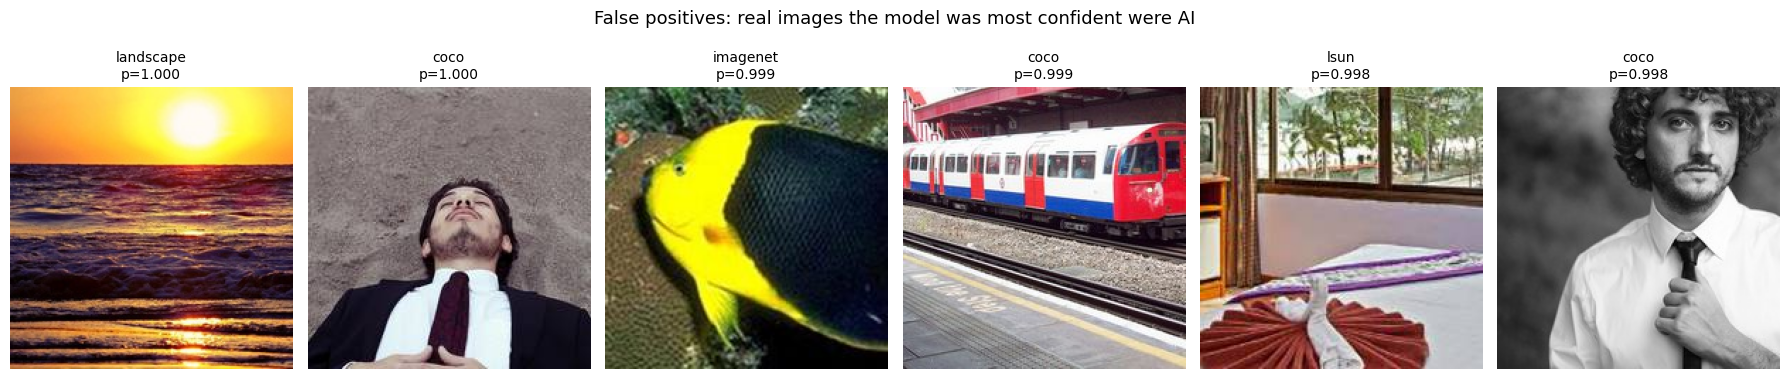

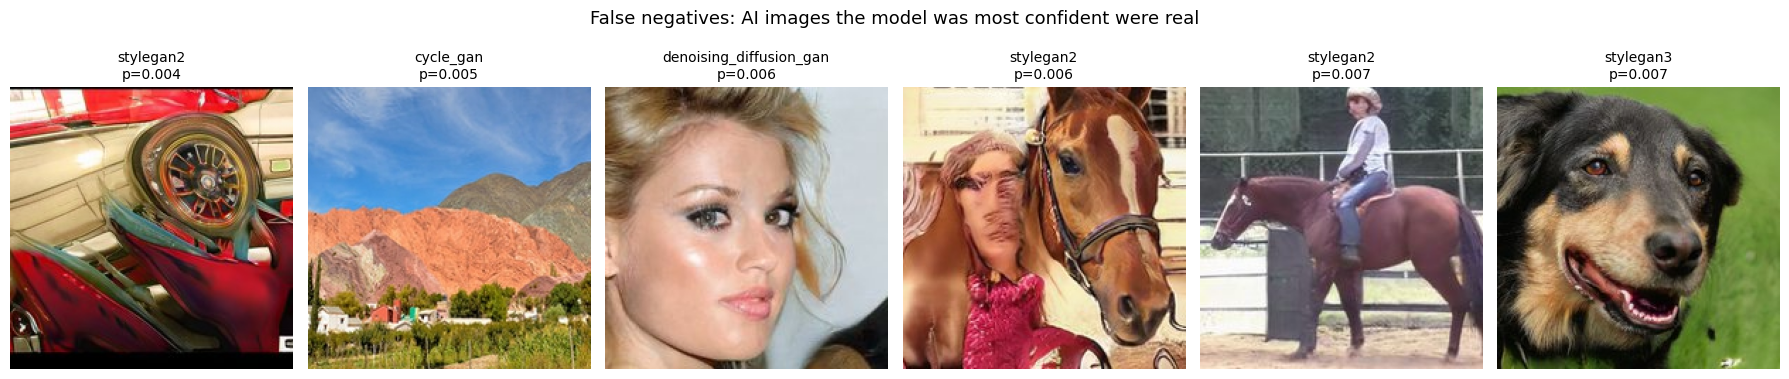

In [14]:
import matplotlib.pyplot as plt
from PIL import Image

fp = err[(err.label == 0) & (err.pred == 1)].nlargest(6, 'prob')   # real, called AI
fn = err[(err.label == 1) & (err.pred == 0)].nsmallest(6, 'prob')  # AI, called real

def grid(rows, title, fname):
    fig, axes = plt.subplots(1, 6, figsize=(18, 3.6))
    for ax, (_, r) in zip(axes, rows.iterrows()):
        ax.imshow(Image.open(r['full_path']).convert('RGB'))
        ax.set_title(f"{r['source']}\np={r['prob']:.3f}", fontsize=10)
        ax.axis('off')
    fig.suptitle(title, fontsize=13, y=1.06)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{fname}', dpi=130, bbox_inches='tight')
    plt.show()

grid(fp, "False positives: real images the model was most confident were AI",
     'false_positives.png')
grid(fn, "False negatives: AI images the model was most confident were real",
     'false_negatives.png')

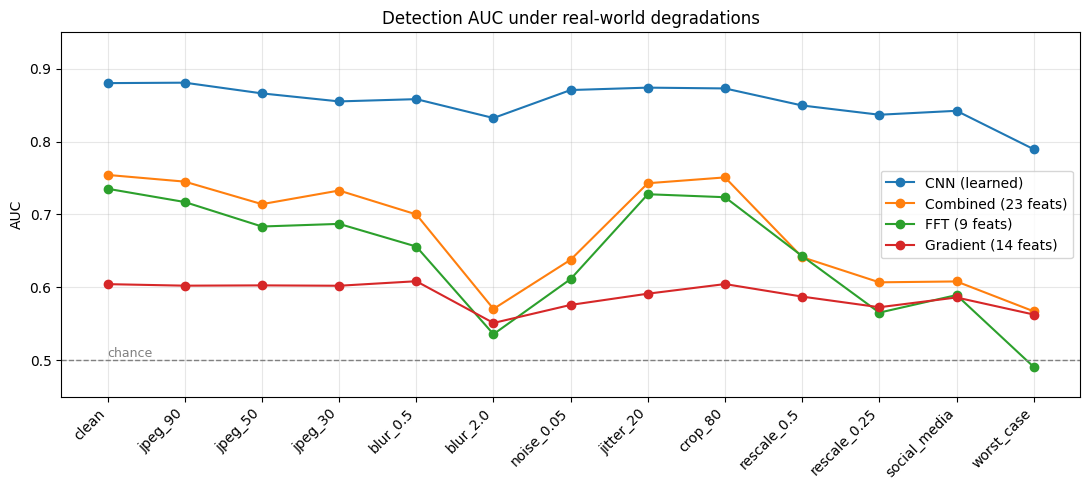

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
for col, lab in [('cnn_auc', 'CNN (learned)'), ('comb_auc', 'Combined (23 feats)'),
                 ('fft_auc', 'FFT (9 feats)'), ('grad_auc', 'Gradient (14 feats)')]:
    ax.plot(robust_df['condition'], robust_df[col], marker='o', label=lab)

ax.axhline(0.5, ls='--', c='gray', lw=1)
ax.text(0, 0.505, 'chance', fontsize=9, color='gray')
ax.set_ylabel('AUC'); ax.set_ylim(0.45, 0.95)
ax.set_title('Detection AUC under real-world degradations')
ax.legend(); ax.grid(alpha=0.3)
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('/kaggle/working/robustness_curve.png', dpi=140, bbox_inches='tight')
plt.show()